## Problem Statement

Given a characters array tasks, representing tasks CPU needs to do, where each letter represents a different task. Tasks could be done in any order. Each task is done in one unit of time. For each unit of time, the CPU could complete either one task or just be idle.

However, there is a non-negative integer n that represents the cooldown period between two same tasks (the same letter in the array). That means there must be at least n units of time between any two same tasks.

Return the least number of units of times that the CPU will take to finish all the given tasks.

### Example 1:

Input: tasks = ["A","A","A","B","B","B"], n = 2
Output: 8
Explanation: 
A -> B -> idle -> A -> B -> idle -> A -> B
There is at least 2 units of time between any two same tasks.

### Example 2:

Input: tasks = ["A","A","A","B","B","B"], n = 0
Output: 6
Explanation: On this case, you can execute tasks in any order, no idle time needed.

### Example 3:

Input: tasks = ["A","A","A","A","A","A","B","C","D","E","F","G"], n = 2
Output: 16
Explanation: 
One possible solution is:
A -> B -> C -> A -> D -> E -> A -> F -> G -> A -> idle -> idle -> A -> idle -> idle -> A

## Constraints:

   - 1 <= tasks.length <= 10^4

   - tasks[i] is upper-case English letter

   - 0 <= n <= 100

In [1]:
import heapq
from collections import deque, Counter

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

In [2]:
# deque as a Queue
#  FIFO first in frist out

dq = deque()

dq.append(1)
dq.append(3)
dq.append(5)

print(" ".join(map(str, dq)), dq[0], dq[1], dq[2])

print(f"{dq.popleft()=}")

print(" ".join(map(str, dq)))

1 3 5 1 3 5
dq.popleft()=1
3 5


In [6]:
# deque as a Stack
#  LIFO last in frist out

dq = deque()

dq.append(1)
dq.append(3)
dq.append(5)

print(" ".join(map(str, dq)))


print(f"{dq.pop()=}")

print(" ".join(map(str, dq)))

1 3 5
dq.pop()=5
1 3


In [7]:
len(dq)

2

In [8]:
dq[-1]

3

$ HEAP

In [5]:
dir(dq)

['__add__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__copy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'append',
 'appendleft',
 'clear',
 'copy',
 'count',
 'extend',
 'extendleft',
 'index',
 'insert',
 'maxlen',
 'pop',
 'popleft',
 'remove',
 'reverse',
 'rotate']

In [ ]:
heap = [(4, "Tokyo"), (1, "Seoul"), (2, "Delhi")]
print(f"Heap before heapify: {heap}")

heapq.heapify(heap)
print(f"Heap after heapify: {heap}")

heapq.heappush(heap, (3, "Jakarta"))
print(f"Heap after push: {heap}")

Heap before heapify: [(4, 'Tokyo'), (1, 'Seoul'), (2, 'Delhi')]
Heap after heapify: [(1, 'Seoul'), (4, 'Tokyo'), (2, 'Delhi')]
Heap after push: [(1, 'Seoul'), (3, 'Jakarta'), (2, 'Delhi'), (4, 'Tokyo')]


[1, 1, 2, 4, 3, 2, 4, 5, 7, 8, 4, 5, 3, 5, 8, 6, 7, 7]


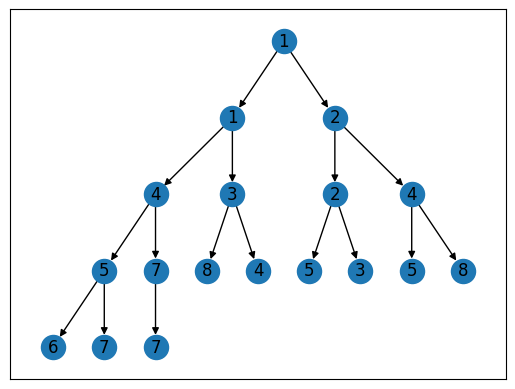

In [18]:
# MinHeap


def heap_to_graph(heap) -> nx.DiGraph:
    g = nx.DiGraph()
    heap_length = len(heap)

    def go(index: int):
        g.add_node(index, value=heap[index])
        if 2 * index + 1 < heap_length:
            g.add_edge(index, 2 * index + 1)
            go(index=2 * index + 1)
        if 2 * index + 2 < heap_length:
            g.add_edge(index, 2 * index + 2)
            go(index=2 * index + 2)

    if heap:
        go(index=0)

    return g


mh = [1, 4, 2, 7, 3, 5, 5, 6, 7, 8, 1, 2, 3, 4, 8, 4, 5, 7]
heapq.heapify(mh)
g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")
print(mh)
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

Smallest: 1
[1, 3, 2, 4, 4, 2, 4, 5, 7, 8, 7, 5, 3, 5, 8, 6, 7]


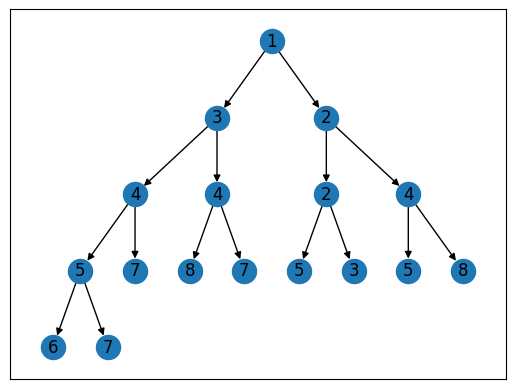

In [19]:
min_value = heapq.heappop(mh)
print("Smallest:", min_value)
g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")
print(mh)
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

Smallest: 2
[-2, 3, 2, 4, 4, 3, 4, 5, 7, 8, 7, 5, 4, 5, 8, 6, 7]


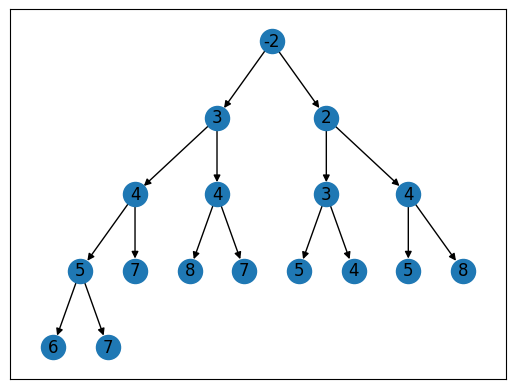

In [21]:
min_value = heapq.heapreplace(mh, -2)
print("Smallest:", min_value)
g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")
print(mh)
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

[-12, 1, 2, 1, 3, 2, 4, 5, 4, 8, 4, 5, 3, 5, 8, 6, 7, 7, 7, 12]


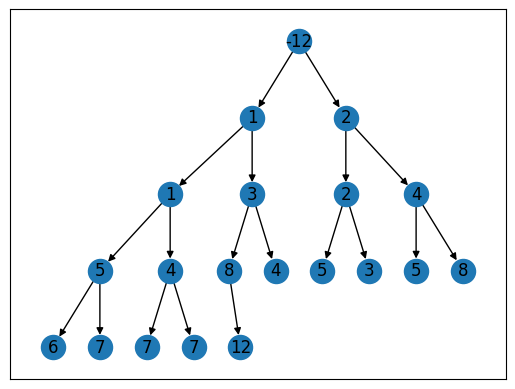

In [ ]:
mh = [1, 4, 2, 7, 3, 5, 5, 6, 7, 8, 1, 2, 3, 4, 8, 4, 5, 7]
heapq.heapify(mh)
heapq.heappush(mh, -12)
heapq.heappush(mh, 12)
print(mh)

g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")

nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

[-8, -8, -5, -7, -4, -5, -4, -6, -7, -3, -1, -2, -3, -1, -2, -4, -5, -7]


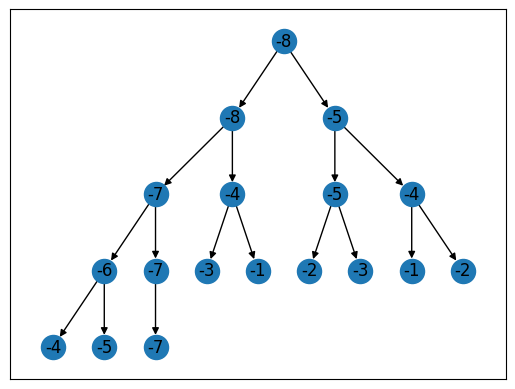

In [34]:
mh = [1, 4, 2, 7, 3, 5, 5, 6, 7, 8, 1, 2, 3, 4, 8, 4, 5, 7]
mh = list(map(lambda x: -x, mh))
heapq.heapify(mh)
print(mh)

g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")

nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

heapq.heappop(mh)=1
mh=[2, 4, 5, 7, 3, 5, 4, 6, 7, 8, 1, 2, 3, 7, 8, 4, 5]


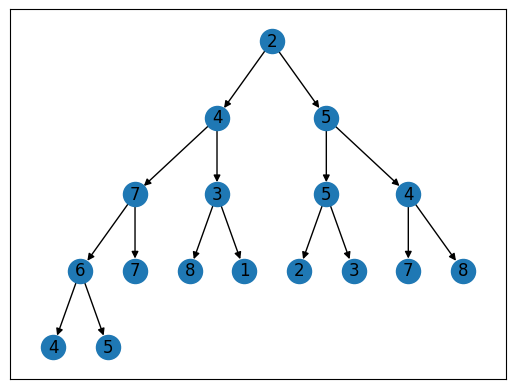

In [30]:
print(f"{heapq.heappop(mh)=}")
print(f"{mh=}")

g = heap_to_graph(heap=mh)
pos = graphviz_layout(g, prog="dot")

nx.draw_networkx(g, labels=nx.get_node_attributes(g, "value"), pos=pos)

In [44]:
test_cases = [
    # (tasks, n, expected)
    (["A", "A", "A", "B", "B", "B"], 2, 8),
    (["A", "A", "A", "B", "B", "B"], 0, 6),
    (["A", "A", "A", "A", "A", "A", "B", "C", "D", "E", "F", "G"], 2, 16),
    (["A", "B", "C", "D", "E", "A", "B", "C", "D", "E"], 4, 10),
    (["A", "A", "A", "B", "B", "B", "C", "C", "C", "D", "D", "E"], 2, 12),
    (["A"], 2, 1),
    (["A", "A", "A", "B", "B", "B", "C", "C", "C"], 1, 9),
    (["A", "A", "A", "B", "B", "B", "C", "C", "C", "D", "D", "D"], 3, 12),
]

In [45]:
def my_least_interval(tasks: list[str], n: int):
    if n == 0:
        return len(tasks)

    task_counts = Counter(tasks)

    mh = [-count for count in task_counts.values()]
    heapq.heapify(mh)

    q = deque()

    time = 0

    while mh or q:
        time += 1

        if mh:
            count = -mh.headpop()
            count -= 1

            if count > 0:
                q.append((time + n, count))

        if q and q[0][0] == time:
            _, count = q.popleft()
            heapq.heappush(-count)

    return time

In [80]:
lst = [1, 2, 3, 4, 5, 6, 7]


def get_last_index(lst: list, value) -> int:
    try:
        index = len(lst) - 1 - lst[::-1].index(value)
    except Exception:
        # print(e)
        index = -1
    return index


def get_first_index(lst: list, value) -> int:
    try:
        index = lst.index(value)
    except Exception:
        # print(e)
        index = -1
    return index


get_last_index(lst, 4), get_first_index(lst, 4)

(3, 3)

In [93]:
def my_scheldure(tasks: list[str], n: int):
    if n == 0:
        return tasks

    task_counts = Counter(tasks)

    mh = [(-count, v) for v, count in task_counts.most_common()]

    heapq.heapify(mh)

    schedule = []

    def update_schedule(v: str, n: int, last: int | None = None):
        index = get_last_index(lst=schedule, value=v)
        if index == -1:
            _ind = get_first_index(lst=schedule, value="idle")
            if _ind == -1:
                schedule.append(v)
            else:
                schedule[_ind] = v
            return 0
        else:
            if index + n < len(schedule):
                if schedule[index + n] == "idle":
                    schedule[index + n] = v
                else:
                    tmp_ind = index + n + 1
                    while True:
                        if tmp_ind < len(schedule):
                            if schedule[tmp_ind] == "idle":
                                schedule.insert(tmp_ind, v)
                            else:
                                tmp_ind += 1
                        else:
                            schedule.append(v)
                            break
            else:
                for i in range(len(schedule), index + n + 1):
                    schedule.append("idle")
                schedule.append(v)

    while mh:
        _count, v = heapq.heappop(mh)
        count = -_count
        for _ in range(count):
            update_schedule(v=v, n=n)

    return schedule


case = test_cases[6]
tasks = case[0]
n = case[1]
print(f"{n=}")
res = my_scheldure(tasks=tasks, n=n)
print(res, len(res), case[2])

n=1


KeyboardInterrupt: 

In [40]:
tasks = ["A", "A", "A", "A", "A", "A", "B", "C", "D", "E", "F", "G"]
n = 2
res = 16

In [42]:
Counter(tasks).most_common()

[('A', 6), ('B', 1), ('C', 1), ('D', 1), ('E', 1), ('F', 1), ('G', 1)]

In [ ]:
def least_interval(tasks, n):
    if n == 0:
        return len(tasks)

    task_counts = Counter(tasks)

    max_heap = [-count for count in task_counts.values()]
    heapq.heapify(max_heap)

    cooldown_queue = deque()

    time = 0

    while max_heap or cooldown_queue:
        print(f"{max_heap=}, {time=}, {cooldown_queue=}")
        time += 1

        if max_heap:
            count = -heapq.heappop(max_heap)  # Get max frequency task
            count -= 1

            if count > 0:
                print(f"{count=}")
                cooldown_queue.append((time + n, count))

        if cooldown_queue and cooldown_queue[0][0] == time:
            available_time, count = cooldown_queue.popleft()
            print(f"{available_time=} {count=}")
            heapq.heappush(max_heap, -count)

    return time


case = test_cases[2]
print(least_interval(tasks=case[0], n=case[1]), case[2])

max_heap=[-6, -1, -1, -1, -1, -1, -1], time=0, cooldown_queue=deque([])
count=5
max_heap=[-1, -1, -1, -1, -1, -1], time=1, cooldown_queue=deque([(3, 5)])
max_heap=[-1, -1, -1, -1, -1], time=2, cooldown_queue=deque([(3, 5)])
available_time=3 count=5
max_heap=[-5, -1, -1, -1, -1], time=3, cooldown_queue=deque([])
count=4
max_heap=[-1, -1, -1, -1], time=4, cooldown_queue=deque([(6, 4)])
max_heap=[-1, -1, -1], time=5, cooldown_queue=deque([(6, 4)])
available_time=6 count=4
max_heap=[-4, -1, -1], time=6, cooldown_queue=deque([])
count=3
max_heap=[-1, -1], time=7, cooldown_queue=deque([(9, 3)])
max_heap=[-1], time=8, cooldown_queue=deque([(9, 3)])
available_time=9 count=3
max_heap=[-3], time=9, cooldown_queue=deque([])
count=2
max_heap=[], time=10, cooldown_queue=deque([(12, 2)])
max_heap=[], time=11, cooldown_queue=deque([(12, 2)])
available_time=12 count=2
max_heap=[-2], time=12, cooldown_queue=deque([])
count=1
max_heap=[], time=13, cooldown_queue=deque([(15, 1)])
max_heap=[], time=14, co

In [56]:
def generate_schedule(tasks, n):
    """Generate one possible optimal schedule"""

    if n == 0:
        return tasks

    task_counts = Counter(tasks)
    max_heap = [-count for count in task_counts.values()]
    heapq.heapify(max_heap)

    # Map negative counts back to tasks
    task_map = {}
    for task, count in task_counts.items():
        task_map[-count] = task

    cooldown_queue = deque()
    schedule = []
    time = 0

    while max_heap or cooldown_queue:
        time += 1

        if max_heap:
            neg_count = heapq.heappop(max_heap)
            count = -neg_count
            task = task_map.get(neg_count, "?")
            schedule.append(task)
            count -= 1

            if count > 0:
                cooldown_queue.append((time + n, count, task))
                task_map[-count] = task
        else:
            schedule.append("idle")

        if cooldown_queue and cooldown_queue[0][0] == time:
            _, count, task = cooldown_queue.popleft()
            heapq.heappush(max_heap, -count)

    return schedule


case = test_cases[2]
tasks = case[0]
n = case[1]
print(f"{tasks=} {n=}")
print(generate_schedule(tasks=tasks, n=n), case[2])

tasks=['A', 'A', 'A', 'A', 'A', 'A', 'B', 'C', 'D', 'E', 'F', 'G'] n=2
['A', 'G', 'G', 'A', 'G', 'G', 'A', 'G', 'G', 'A', 'idle', 'idle', 'A', 'idle', 'idle', 'A'] 16


Max-Heap with Cool-down Tracking

In [58]:
def least_interval2(tasks, n):
    # Count frequencies
    count = Counter(tasks)
    max_heap = [-cnt for cnt in count.values()]
    heapq.heapify(max_heap)

    time = 0
    cooldown = {}  # task -> time when it becomes available

    while max_heap or cooldown:
        time += 1

        # Check cooldown tasks that are now available
        available_tasks = []
        for task, available_time in list(cooldown.items()):
            if available_time <= time:
                available_tasks.append(task)

        for task in available_tasks:
            del cooldown[task]
            # Push back to heap (we need the count, simplified version)
            # This version tracks tasks by letter, not just count

        # Execute a task if available
        if max_heap:
            cnt = -heapq.heappop(max_heap)
            cnt -= 1
            if cnt > 0:
                # In real implementation, we'd track which task this was
                # For simplicity, we're tracking counts only
                heapq.heappush(max_heap, -cnt)
                # Actually need to put in cooldown with task ID

    return time


case = test_cases[2]
tasks = case[0]
n = case[1]
print(f"{tasks=} {n=}")
print(least_interval2(tasks=tasks, n=n), case[2])

tasks=['A', 'A', 'A', 'A', 'A', 'A', 'B', 'C', 'D', 'E', 'F', 'G'] n=2
12 16


In [ ]:
def test_least_interval():
    test_cases = [
        # (tasks, n, expected)
        (["A", "A", "A", "B", "B", "B"], 2, 8),
        (["A", "A", "A", "B", "B", "B"], 0, 6),
        (["A", "A", "A", "A", "A", "A", "B", "C", "D", "E", "F", "G"], 2, 16),
        (["A", "B", "C", "D", "E", "A", "B", "C", "D", "E"], 4, 10),
        (["A", "A", "A", "B", "B", "B", "C", "C", "C", "D", "D", "E"], 2, 12),
        (["A"], 2, 1),
        (["A", "A", "A", "B", "B", "B", "C", "C", "C"], 1, 9),
        (["A", "A", "A", "B", "B", "B", "C", "C", "C", "D", "D", "D"], 3, 12),
    ]

    for i, (tasks, n, expected) in enumerate(test_cases):
        result = least_interval2(tasks, n)

        if result == expected:
            print(f"Test {i + 1} passed ✓ (got {result})")
        else:
            print(f"Test {i + 1} failed ✗")
            print(f"  Expected: {expected}")
            print(f"  Got: {result}")

            # Show visualization for debugging
            print(f"  Tasks: {tasks}, n={n}")

            # Try to generate schedule
            schedule = generate_schedule(tasks, n)
            if schedule:
                print(f"Sample schedule: {' -> '.join(schedule)}")


test_least_interval()

Test 1 failed ✗
  Expected: 8
  Got: 6
  Tasks: ['A', 'A', 'A', 'B', 'B', 'B'], n=2
  Sample schedule: B -> B -> idle -> B -> B -> idle -> B -> B
Test 2 passed ✓ (got 6)
Test 3 failed ✗
  Expected: 16
  Got: 12
  Tasks: ['A', 'A', 'A', 'A', 'A', 'A', 'B', 'C', 'D', 'E', 'F', 'G'], n=2
  Sample schedule: A -> G -> G -> A -> G -> G -> A -> G -> G -> A -> idle -> idle -> A -> idle -> idle -> A
Test 4 passed ✓ (got 10)
Test 5 passed ✓ (got 12)
Test 6 passed ✓ (got 1)
Test 7 passed ✓ (got 9)
Test 8 passed ✓ (got 12)


Task Scheduler with Priorities (Weighted Tasks)

In [62]:
def weightedTaskScheduler(tasks, priorities, n):
    """
    tasks: list of task IDs
    priorities: list of priorities (higher = more important)
    n: cooldown period
    """
    import heapq

    # Max-heap of (priority, task_id)
    max_heap = []
    for task, priority in zip(tasks, priorities):
        heapq.heappush(max_heap, (-priority, task))

    time = 0
    cooldown = {}  # task_id -> time_when_available

    schedule = []

    while max_heap or cooldown:
        time += 1

        # Find available task with highest priority
        available = []
        temp_heap = []

        while max_heap:
            priority, task = heapq.heappop(max_heap)
            if task not in cooldown or cooldown[task] < time:
                # This task is available
                schedule.append((time, task))
                cooldown[task] = time + n
                # Push remaining tasks back
                while temp_heap:
                    heapq.heappush(max_heap, temp_heap.pop())
                break
            else:
                temp_heap.append((priority, task))

        # If no available task, idle
        if not schedule or schedule[-1][0] != time:
            schedule.append((time, "idle"))

        # Restore heap
        while temp_heap:
            heapq.heappush(max_heap, temp_heap.pop())

    return schedule


case = test_cases[2]
tasks = case[0]
n = case[1]
print(f"{tasks=} {n=}")
print(generate_schedule(tasks=tasks, n=n), case[2])

tasks=['A', 'A', 'A', 'A', 'A', 'A', 'B', 'C', 'D', 'E', 'F', 'G'] n=2
['A', 'G', 'G', 'A', 'G', 'G', 'A', 'G', 'G', 'A', 'idle', 'idle', 'A', 'idle', 'idle', 'A'] 16
